# Lab 7


In [1]:
## init libs
import numpy as np
import cv2 as cv
from math import pi
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure, gca, imshow, plot, show, subplot
from numpy.fft import fft2, fftshift
from numpy.fft import ifft2, ifftshift
from multiprocessing.pool import ThreadPool
%matplotlib inline

## Random Sample Consensus(RANSAC)
RANSAC is a model estimation technique used to process data containing large amounts of noise. It finds the model parameters that best fit the data through random sampling and iteration.There are steps as follow:
- Random sampling: sample a small set from the data, for example, two points is enough for fitting line
- Calculate models' parameters
- Judge inlier data by threshold
- Choose suitable model by quantity of inlier data
- Iteration above steps
- Model optimization: use inlier data to fitting new model

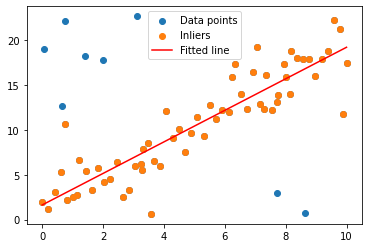

In [28]:
def ransac_line_fitting(points, n_iterations, threshold):
    best_model = None
    best_inliers = []
    
    for _ in range(n_iterations):
        # Random sampling
        sample_indices = np.random.choice(len(points), 2, replace=False)
        sample_points = points[sample_indices]
        
        # Calculate models' parameters
        x1, y1 = sample_points[0]
        x2, y2 = sample_points[1]
        kr = (y2 - y1) / (x2 - x1)
        br = y1 - kr * x1
        
        # Judge inlier data
        distances = np.abs(a * points[:, 0] - points[:, 1] + b) / np.sqrt(a**2 + 1)
        inliers = points[distances < threshold]
        
        # Choose suitable model
        if len(inliers) > len(best_inliers):
            best_model = (kr, br)
            best_inliers = inliers
    
    # Model optimization
    if len(best_inliers) > 1:
        x = best_inliers[:, 0]
        y = best_inliers[:, 1]
        kr, br = np.polyfit(x, y, 1)
        best_model = (kr, br)
    
    return best_model, best_inliers

np.random.seed(42)
n_points=50
k=2.0 # k:y=kx+b
b=1.0 # b:y=kx+b

x = np.linspace(0, 10, n_points)
y_true = k * x + b + np.random.normal(0, 2, n_points)
points = np.column_stack((x, y_true))

# add noise
n_outliers = 20
outliers_x = np.random.uniform(0, 10, n_outliers)
outliers_y = np.random.uniform(0, 25, n_outliers)
points = np.vstack((points, np.column_stack((outliers_x, outliers_y))))

# RANSAC parameter
n_iterations = 100
threshold = 5.0

best_model, best_inliers = ransac_line_fitting(points, n_iterations, threshold)

# show
plt.scatter(points[:, 0], points[:, 1], label="Data points")
plt.scatter(best_inliers[:, 0], best_inliers[:, 1], label="Inliers")
if best_model is not None:
    a, b = best_model
    x_line = np.linspace(0, 10, 100)
    y_line = a * x_line + b
    plt.plot(x_line, y_line, color='red', label="Fitted line")
plt.legend()
plt.show()

Fitting circle using RANSAC

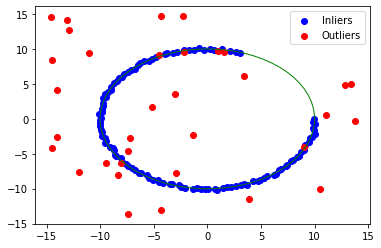

In [2]:
from skimage.measure import CircleModel, ransac

# create circle data
np.random.seed(0)
n_points = 150
t = np.linspace(0, 2 * np.pi, n_points)
x = 10 * np.cos(t) + np.random.normal(scale=0.1, size=n_points)
y = 10 * np.sin(t) + np.random.normal(scale=0.1, size=n_points)

# add noise
x[:30] = np.random.uniform(-15, 15, 30)
y[:30] = np.random.uniform(-15, 15, 30)

data = np.column_stack([x, y])

# ransac fitting
model_robust, inliers = ransac(data, CircleModel, min_samples=3,
                              residual_threshold=0.2, max_trials=1000)

fig, ax = plt.subplots()
ax.scatter(data[inliers, 0], data[inliers, 1], color='blue', label='Inliers')
ax.scatter(data[~inliers, 0], data[~inliers, 1], color='red', label='Outliers')

circle = plt.Circle((model_robust.params[0], model_robust.params[1]),
                    model_robust.params[2], fill=False, color='green')
ax.add_patch(circle)
ax.legend()
plt.show()

## Image Alignment
### Detect feature points in both images
Here we use sift to detect
- Build Gauss pyramid
- Build DoG pyramid
- Find features with direction and scale in DoG
- The simplified version has no optimizations

### Find corresponding pairs
There are many algorithms to match the key points, like KNN

### Use these pairs to align images

Detected 200 keypoints


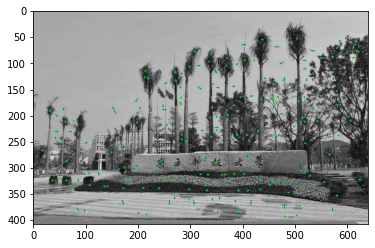

In [22]:
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d

import numpy as np
from scipy.ndimage import gaussian_filter, sobel
import cv2

def compute_gradient(image):
    """
    计算图像的梯度幅值和方向
    """
    dx = sobel(image, axis=1, mode='constant')  # 水平梯度
    dy = sobel(image, axis=0, mode='constant')  # 垂直梯度
    magnitude = np.sqrt(dx ** 2 + dy ** 2)  # 梯度幅值
    orientation = np.arctan2(dy, dx) * (180 / np.pi)  # 梯度方向（角度）
    orientation[orientation < 0] += 360  # 将方向转换为 [0, 360) 范围
    return magnitude, orientation

def compute_orientation_histogram(magnitude, orientation, center, size, num_bins=36):
    """
    计算关键点周围区域的梯度方向直方图
    """
    hist = np.zeros(num_bins)
    bin_width = 360 / num_bins
    radius = int(round(size * 1.5))  # 区域半径
    x, y = int(round(center[0])), int(round(center[1]))

    for i in range(-radius, radius + 1):
        for j in range(-radius, radius + 1):
            if (x + i >= 0 and x + i < magnitude.shape[1] and
                y + j >= 0 and y + j < magnitude.shape[0]):
                dist = np.sqrt(i ** 2 + j ** 2)
                if dist <= radius:
                    bin_idx = int(np.floor(orientation[y + j, x + i] / bin_width))
                    hist[bin_idx % num_bins] += magnitude[y + j, x + i] * np.exp(-0.5 * (dist / (0.5 * size)) ** 2)

    return hist

def build_gaussian_pyramid(image, num_octaves, num_scales, sigma):
    #
    pyramid = []
    k = 2 ** (1 / num_scales)
    for octave in range(num_octaves):
        octave_images = []
        for scale in range(num_scales + 3):  # +3 for DoG
            if octave == 0 and scale == 0:
                octave_images.append(image)
            elif scale == 0:
                # down sampling
                octave_images.append(cv2.resize(pyramid[octave - 1][-3], 
                                            (0, 0), fx=0.5, fy=0.5, 
                                            interpolation=cv2.INTER_NEAREST))
            else:
                # blur
                sigma_total = sigma * (k ** scale)
                octave_images.append(gaussian_filter(octave_images[scale - 1], sigma_total))
        pyramid.append(octave_images)
    return pyramid

def build_dog_pyramid(gaussian_pyramid):
    # 
    dog_pyramid = []
    for octave in gaussian_pyramid:
        dog_octave = []
        for i in range(1, len(octave)):
            dog_octave.append(octave[i] - octave[i - 1])
        dog_pyramid.append(dog_octave)
    return dog_pyramid

def find_keypoints(dog_pyramid, threshold=0.01):
    #
    keypoints = []
    for octave_idx, octave in enumerate(dog_pyramid):
        for scale_idx in range(1, len(octave) - 1):
            magnitude, orientation = compute_gradient(octave[scale_idx])
            for i in range(1, octave[scale_idx].shape[0] - 1):
                for j in range(1, octave[scale_idx].shape[1] - 1):
                    #  3x3x3 
                    patch = np.stack([
                        octave[scale_idx - 1][i - 1:i + 2, j - 1:j + 2],
                        octave[scale_idx][i - 1:i + 2, j - 1:j + 2],
                        octave[scale_idx + 1][i - 1:i + 2, j - 1:j + 2]
                    ])
                    center = patch[1, 1, 1]
                    if abs(center) > threshold and (
                        (center == patch.max()) or (center == patch.min())
                    ):
                        
                        x = j * (2 ** octave_idx)
                        y = i * (2 ** octave_idx)
                        size = 1.6 * (2 ** octave_idx)
                        response = center  
                        
                        hist = compute_orientation_histogram(magnitude, orientation, (j, i), size)
                        angle = np.argmax(hist) * (360 / len(hist))  

                        keypoints.append((x, y, size, angle, response))
    return keypoints

image = cv.imread('rock1.jpg')
image = cv.cvtColor(image,cv.COLOR_RGB2GRAY)
image = image.astype(np.float32) / 255.0

num_octaves = 4
num_scales = 3
sigma = 1.6

gaussian_pyramid = build_gaussian_pyramid(image, num_octaves, num_scales, sigma)
dog_pyramid = build_dog_pyramid(gaussian_pyramid)
keypoints = find_keypoints(dog_pyramid)
  
print(f"Detected {len(keypoints)} keypoints")

output_image = cv.cvtColor((image * 255).astype(np.uint8), cv.COLOR_GRAY2BGR)
for kp in keypoints:
    x, y, size, angle, response = kp
    cv.circle(output_image, (x, y), 2, (0, 255, 0), -1)
    # angle
    dx = size * np.cos(np.deg2rad(angle))
    dy = size * np.sin(np.deg2rad(angle))
    cv.line(output_image, (int(x), int(y)), (int(x + dx), int(y + dy)), (0, 0, 255), 1)

figure(figsize=(6, 8))
imshow(output_image)
show()



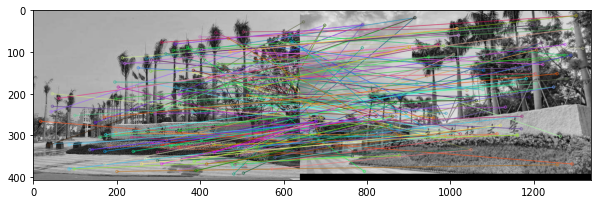

In [46]:


num_octaves = 4
num_scales = 3
sigma = 1.6

img1 = cv.imread('rock1.jpg')
img1 = cv.cvtColor(img1,cv.COLOR_RGB2GRAY)
img1g = img1.astype(np.float32) / 255.0

gaussian_pyramid = build_gaussian_pyramid(img1g, num_octaves, num_scales, sigma)
dog_pyramid = build_dog_pyramid(gaussian_pyramid)
kp1 = find_keypoints(dog_pyramid)

img2 = cv.imread('rock2.png')
img2 = cv.cvtColor(img2,cv.COLOR_RGB2GRAY)
img2g = img2.astype(np.float32) / 255.0

gaussian_pyramid = build_gaussian_pyramid(img2g, num_octaves, num_scales, sigma)
dog_pyramid = build_dog_pyramid(gaussian_pyramid)
kp2 = find_keypoints(dog_pyramid)
arr1= np.array([row[-3:] for row in kp1], dtype=np.float32)
arr2= np.array([row[-3:] for row in kp2], dtype=np.float32)
# print(arr1)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)  
flann = cv.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(arr1, arr2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

# tuple-->cv2.KeyPoint
cvkps1 = []
for row in kp1:
    x, y, size, angle, response = row
    keypoint = cv.KeyPoint(
        x=x, y=y, size=size, angle=angle, response=response,
        octave=0, class_id=-1
    )
    cvkps1.append(keypoint)
    
cvkps2 = []
for row in kp2:
    x, y, size, angle, response = row
    keypoint = cv.KeyPoint(
        x=x, y=y, size=size, angle=angle, response=response,
        octave=0, class_id=-1
    )
    cvkps2.append(keypoint)

matched_image = cv2.drawMatches(
    img1, cvkps1, img2, cvkps2, good_matches, None,
    None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)     
figure(figsize=(10, 20))
imshow(matched_image)
show()

## Principal Component Analysis(PCA)
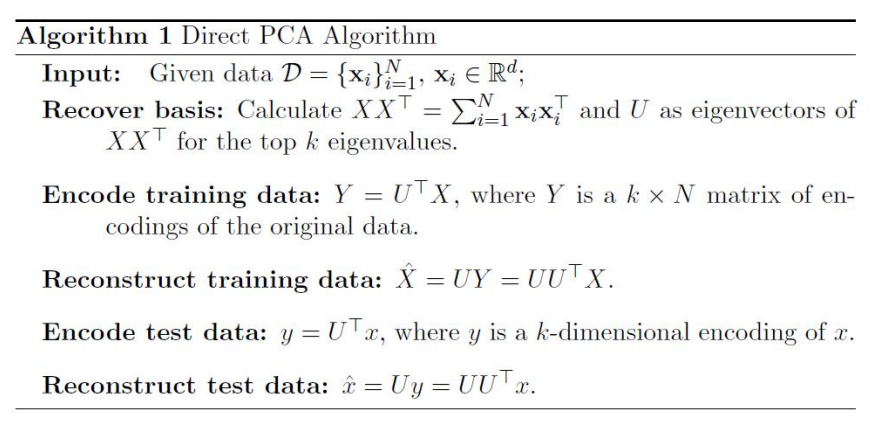

<Figure size 576x432 with 0 Axes>

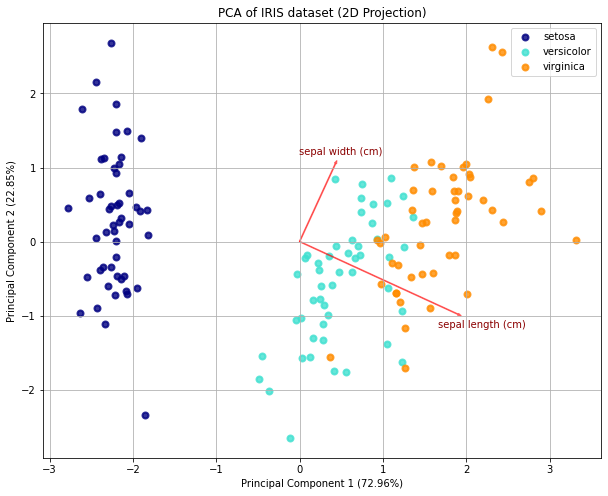

var ratio (every main Component): [0.72962445 0.22850762]
cumsum: [0.72962445 0.95813207]


In [9]:
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# load data
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Standard data
X_scaled = StandardScaler().fit_transform(X)

# reduce 4dim to 2 dim
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# visualization
plt.figure(figsize=(8, 6))
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                color=color, alpha=0.8, lw=2,
                label=target_name)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA of IRIS dataset (2D Projection)')
plt.xlabel('Principal Component 1 (%.2f%%)' % (pca.explained_variance_ratio_[0]*100))
plt.ylabel('Principal Component 2 (%.2f%%)' % (pca.explained_variance_ratio_[1]*100))

# add arrow 4 pc
for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_ratio_)):
    comp = comp * var * 5 
    plt.arrow(0, 0, comp[0], comp[1], color='r', alpha=0.5,
              linewidth=1, width=0.01)
    plt.text(comp[0]*1.15, comp[1]*1.15, iris.feature_names[i],
             color='darkred', ha='center', va='center')

plt.grid()
plt.show()

# var_ration
print("var ratio (every main Component):", pca.explained_variance_ratio_)# mean pc1-72.962445%; pc2-2.2850762%
print("cumsum:", np.cumsum(pca.explained_variance_ratio_))#pc1-72.962445%; pc1+pc2-95.813207%